In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [8]:
df=pd.read_csv("/content/gold_monthly_csv.csv")

In [9]:
df.head()

,Date,Price
0,1950-01,34.73
1,1950-02,34.73
2,1950-03,34.73
3,1950-04,34.73
4,1950-05,34.73


In [10]:
# setting Name as index

df = df.set_index('Date')

In [11]:
df.head()

,Price
Date,
1950-01,34.73
1950-02,34.73
1950-03,34.73
1950-04,34.73
1950-05,34.73


In [12]:


df.index  # confirmed it is a datetime index

Index(['1950-01', '1950-02', '1950-03', '1950-04', '1950-05', '1950-06',
       '1950-07', '1950-08', '1950-09', '1950-10',
       ...
       '2019-10', '2019-11', '2019-12', '2020-01', '2020-02', '2020-03',
       '2020-04', '2020-05', '2020-06', '2020-07'],
      dtype='object', name='Date', length=847)

In [13]:
df.describe()

,Price
count,847.000000
mean,416.556906
std,453.665313
min,34.490000
25%,35.190000
50%,319.622000
75%,447.029000
max,1840.807000


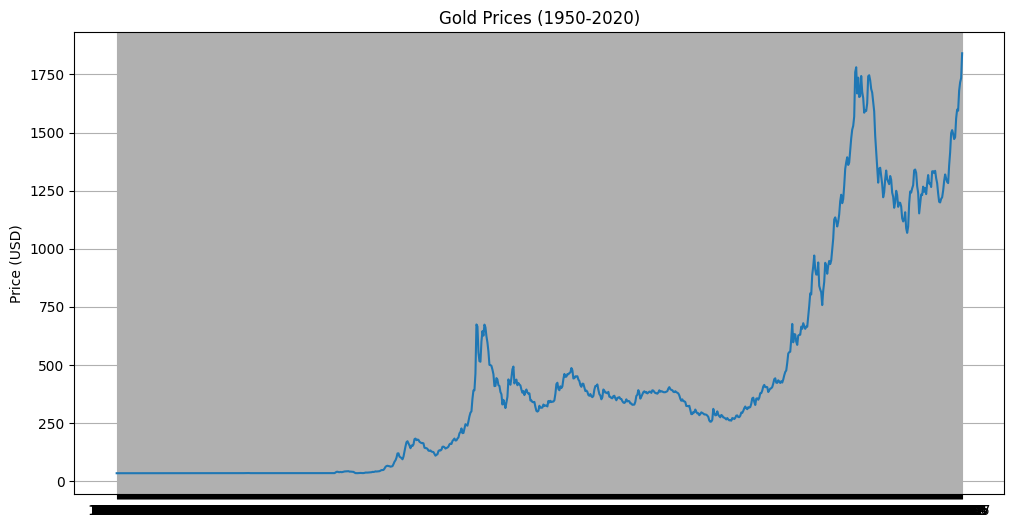

In [14]:
# Plot raw data
plt.figure(figsize=(12,6))
plt.plot(df)
plt.title('Gold Prices (1950-2020)')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

In [74]:
# Decomposition
#decomposition = seasonal_decompose(df['Price'], model='additive', period=12)# the period =12 assume monthly seasonality
#decomposition.plot()
#plt.show()

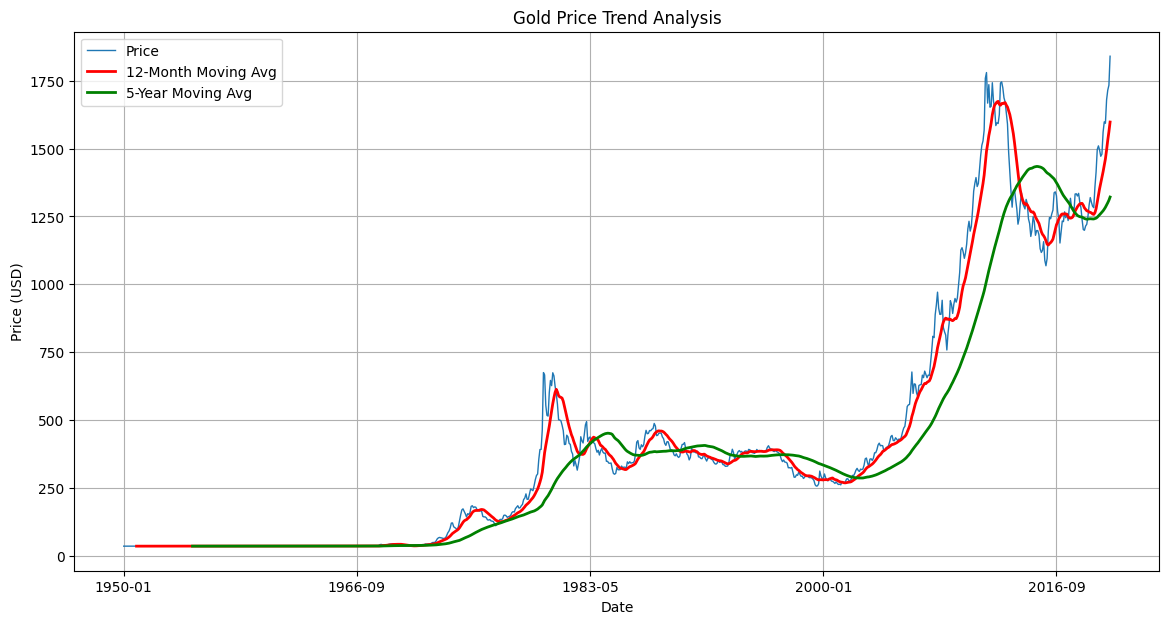

In [15]:
# 1. Trend Detection
plt.figure(figsize=(14, 7))
df['Price'].plot(title='Gold Price Trend Analysis', linewidth=1)
df['Price'].rolling(window=12).mean().plot(linewidth=2, color='red', label='12-Month Moving Avg')
df['Price'].rolling(window=60).mean().plot(linewidth=2, color='green', label='5-Year Moving Avg')
plt.legend()
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

The Gold prices have mostly **gone up** over time, especially after **2005**.
There were some **big jumps** and drops around 1980 and 2011.
The red and green lines make it easier to see short-term and long-term changes in the price.










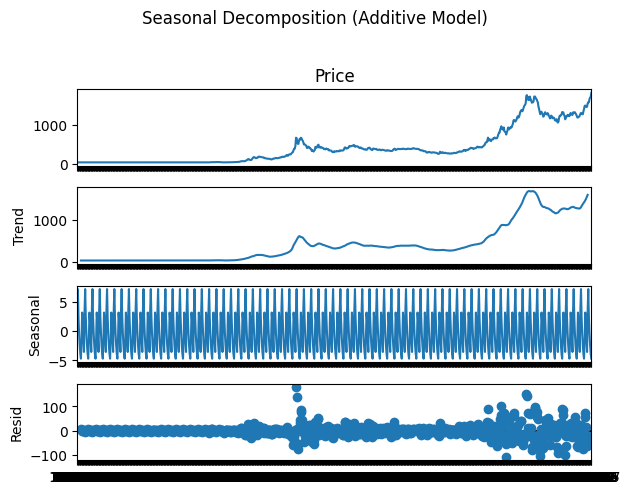

In [16]:
# 2. Seasonality Analysis
decomposition = seasonal_decompose(df['Price'], model='additive', period=12)
decomposition.plot()
plt.suptitle('Seasonal Decomposition (Additive Model)', y=1.02)
plt.tight_layout()
plt.show()

It shows a clear long-term **upward trend**, consistent **seasonal** fluctuations, and increased irregular variations  that is residuals in recent decades. This suggests that both trend and random shocks have played a significant role in price changes over time.

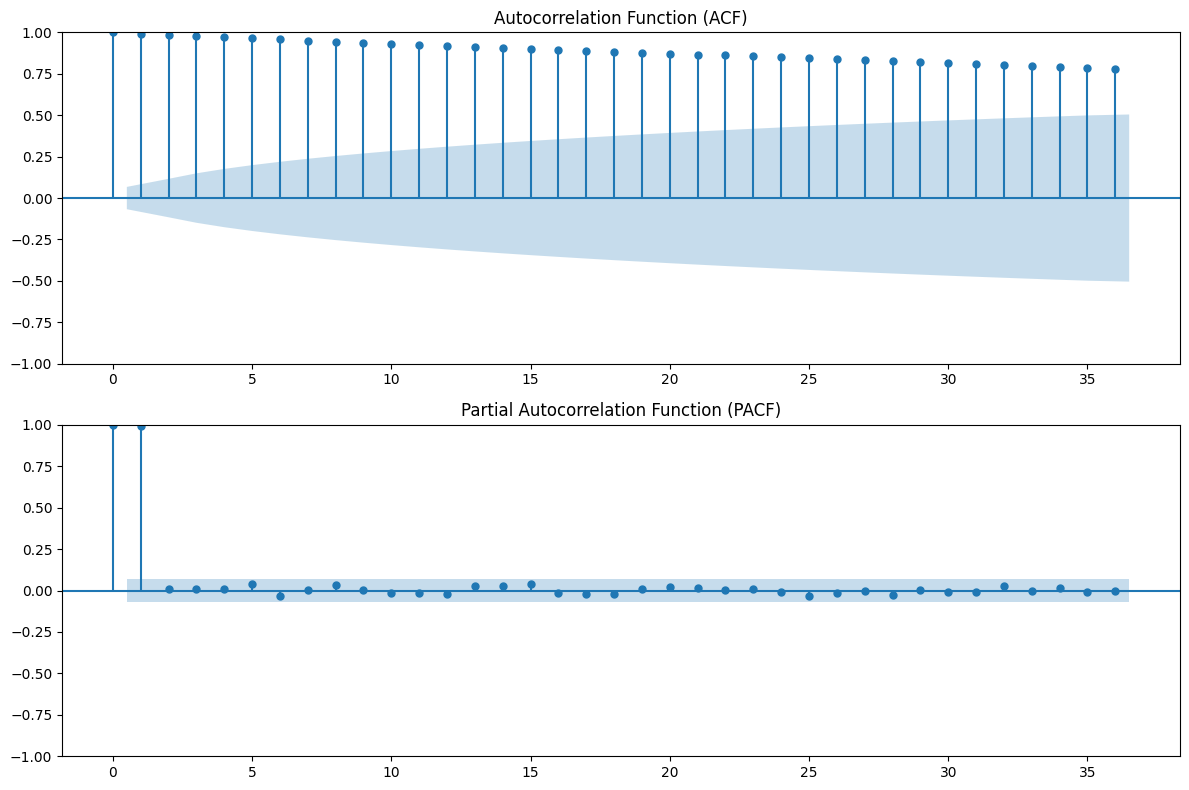

In [17]:

# ACF/PACF for seasonality confirmation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['Price'], lags=36, ax=ax1, title='Autocorrelation Function (ACF)')
plot_pacf(df['Price'], lags=36, ax=ax2, title='Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

This graph shows the ACF and PACF plots of a time series. The ACF (top) indicates **strong autocorrelation** that slowly decays, suggesting the data is non-stationary, The PACF (bottom) shows a sharp cutoff after lag 1, which means an AR(1) model might be suitable after differencing

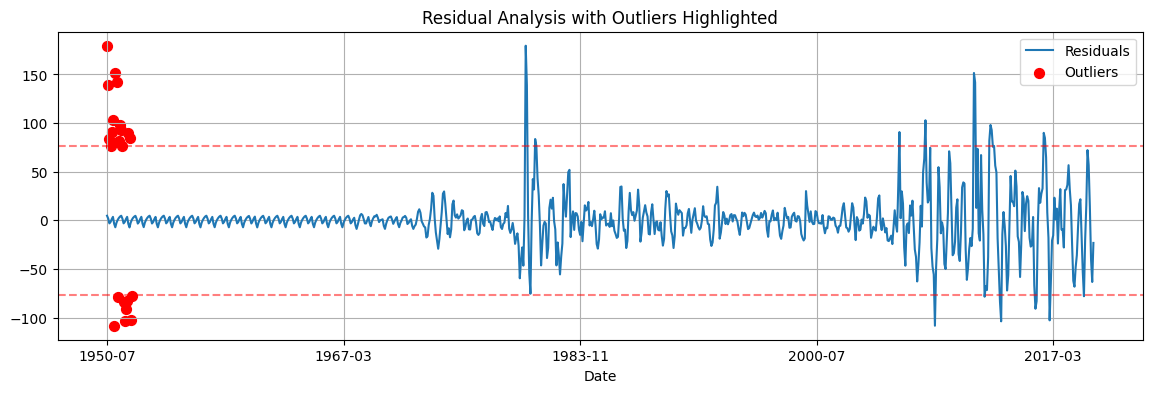

Detected Outliers:
Date
1980-01    179.527781
2011-08    151.501304
2011-09    141.778880
1980-02    139.017478
2008-03    102.870913
2012-10     98.010587
2012-11     92.812998
2006-05     90.744299
2016-07     89.923173
2016-08     84.714929
1980-09     83.583630
2012-09     81.812839
1980-10     76.520296
2013-01     76.481823
2019-05    -78.086743
2012-05    -78.565451
2016-01    -83.070802
2013-06    -83.633080
2015-12    -90.947496
2016-12   -102.883288
2013-07   -103.887368
2008-11   -108.402461
Name: resid, dtype: float64


In [18]:

# 3. Outlier Detection
residuals = decomposition.resid.dropna()
mean_resid = residuals.mean()
std_resid = residuals.std()

# Define outliers (3 standard deviations)
outliers = residuals[(residuals - mean_resid).abs() > 3 * std_resid]

plt.figure(figsize=(14, 4))
residuals.plot(label='Residuals')
plt.scatter(outliers.index, outliers, color='red', s=50, label='Outliers')
plt.axhline(mean_resid + 3*std_resid, color='r', linestyle='--', alpha=0.5)
plt.axhline(mean_resid - 3*std_resid, color='r', linestyle='--', alpha=0.5)
plt.title('Residual Analysis with Outliers Highlighted')
plt.legend()
plt.grid(True)
plt.show()

# Print outlier dates and values
print("Detected Outliers:")
print(outliers.sort_values(ascending=False))

In [19]:
from statsmodels.tsa.stattools import adfuller

# ADF Test
result = adfuller(df['Price'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# Differencing if non-stationary
df['diff'] = df['Price'].diff().dropna()

ADF Statistic: 0.8143240077835251
p-value: 0.9918639010465631


**ADF** Statistic = 0.814

p-value = 0.992

**Interpretation:**
**Our** gold price time series is non-stationary

since our p value is larger than the ADF test statistic,  so here non -stationary

In [20]:
# First-order differencing
df['Price_diff'] = df['Price'].diff().dropna()

# Re-run ADF test
result = adfuller(df['Price_diff'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -6.217086926407337
p-value: 5.33328251334224e-08


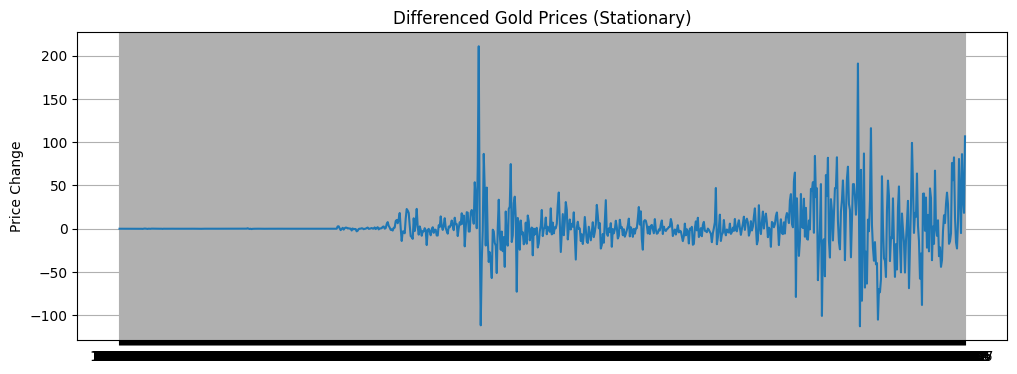

In [21]:
plt.figure(figsize=(12,4))
plt.plot(df['Price_diff'])
plt.title('Differenced Gold Prices (Stationary)')
plt.ylabel('Price Change')
plt.grid(True)
plt.show()

In [31]:
df.head()

,Price,diff,Price_diff
Date,,,
1950-01,34.73,NaN,NaN
1950-02,34.73,0.0,0.0
1950-03,34.73,0.0,0.0
1950-04,34.73,0.0,0.0
1950-05,34.73,0.0,0.0


In [22]:
print(f"Missing values: {df.isnull().sum()}")

Missing values: Price         0
diff          1
Price_diff    1
dtype: int64


**ARIMA MODEL**

In [2]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from math import sqrt

In [23]:
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")

Train size: 677
Test size: 170


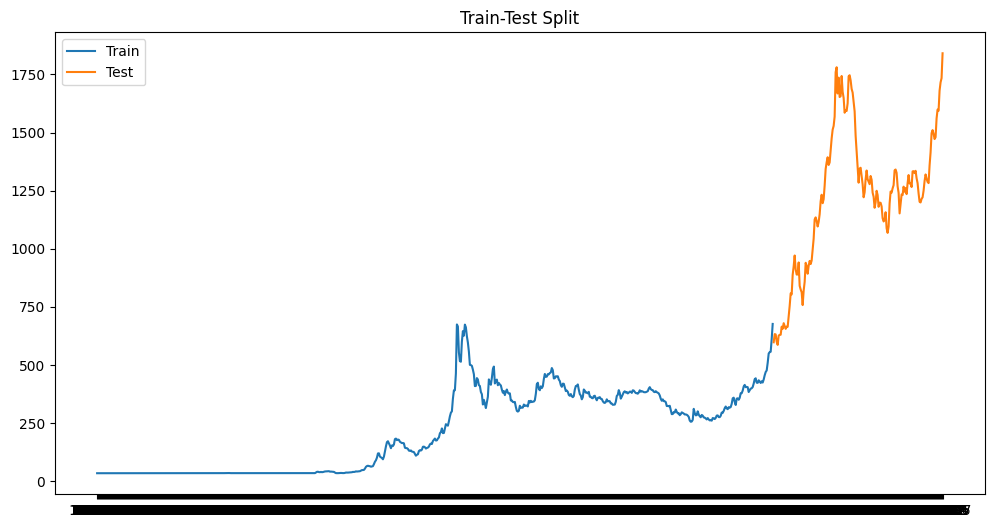

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(train['Price'], label='Train')
plt.plot(test['Price'], label='Test')
plt.title('Train-Test Split')
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                  677
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2761.010
Date:                Sat, 03 May 2025   AIC                           5528.020
Time:                        19:41:38   BIC                           5541.569
Sample:                    01-01-1950   HQIC                          5533.266
                         - 05-01-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3365      0.028    -11.997      0.000      -0.391      -0.281
ma.L1          0.7259      0.026     28.219      0.000       0.676       0.776
sigma2       206.5068      2.840     72.726      0.0

<ipython-input-24-e35275d2da7a>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ARIMA_Forecast'] = arima_forecast


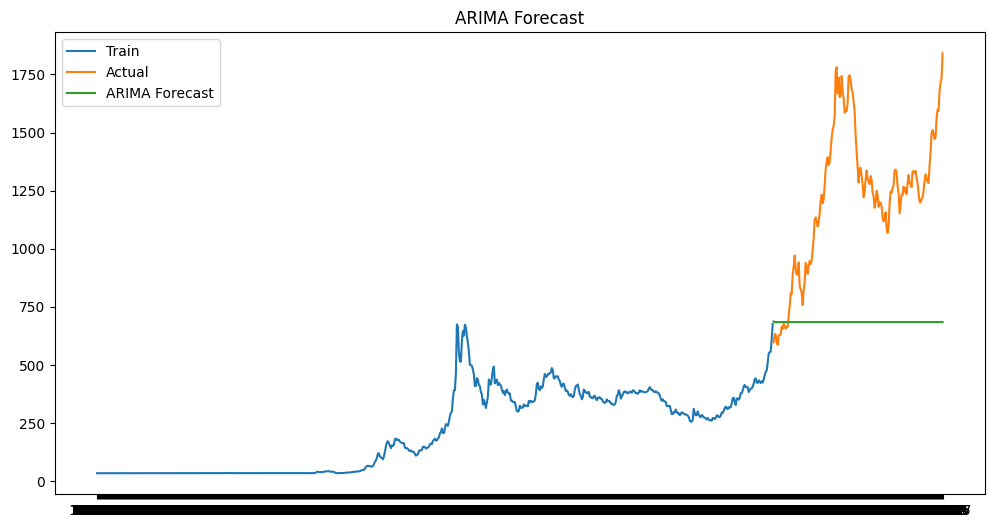

In [24]:
# Fit ARIMA model
model = ARIMA(train['Price'], order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

# Forecast on test set
arima_forecast = model_fit.forecast(steps=len(test))
test['ARIMA_Forecast'] = arima_forecast

# Plot forecasts
plt.figure(figsize=(12, 6))
plt.plot(train['Price'], label='Train')
plt.plot(test['Price'], label='Actual')
plt.plot(test['ARIMA_Forecast'], label='ARIMA Forecast')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()

Evaluate **RMSE** ARIMA Model :

In [29]:
# Calculate evaluation metrics
arima_rmse = sqrt(mean_squared_error(test['Price'], test['ARIMA_Forecast']))
arima_mae = mean_absolute_error(test['Price'], test['ARIMA_Forecast'])

print(f"ARIMA RMSE: {arima_rmse:.2f}")
print(f"ARIMA MAE: {arima_mae:.2f}")

ARIMA RMSE: 617.90
ARIMA MAE: 547.68


MACHINE LEARNING MODEL **RANDOM FOREST**

In [33]:
# Create time series features
def create_features(df):
    df = df.copy()
    df = df.reset_index() # Reset index to access 'Date' column
    df['month'] = pd.to_datetime(df['Date']).dt.month  # Extract month from 'Date' column
    df['year'] = pd.to_datetime(df['Date']).dt.year   # Extract year from 'Date' column
    df['lag1'] = df['Price'].shift(1)
    df['lag12'] = df['Price'].shift(12)  # yearly seasonality
    df['rolling_mean_12'] = df['Price'].rolling(window=12).mean()
    return df

**HANDLING MISSING VALUES**

In [34]:
# Drop rows with missing values (from lag/rolling features)
df_clean = df.dropna()

# Verify
print(df_clean.head())
print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")

         Price  diff  Price_diff
Date                            
1950-02  34.73   0.0         0.0
1950-03  34.73   0.0         0.0
1950-04  34.73   0.0         0.0
1950-05  34.73   0.0         0.0
1950-06  34.73   0.0         0.0
Original shape: (847, 3)
Clean shape: (846, 3)


In [52]:
## Create time series features
def create_features(df):
    df = df.copy()
    df = df.reset_index()  # Reset index to access 'Date' column
    # Convert 'Date' to datetime if it's not already
    df['Date'] = pd.to_datetime(df['Date'])
    df['month'] = df['Date'].dt.month  # Extract month from 'Date' column
    df['year'] = df['Date'].dt.year   # Extract year from 'Date' column
    df['lag1'] = df['Price'].shift(1)
    df['lag12'] = df['Price'].shift(12)  # yearly seasonality
    df['rolling_mean_12'] = df['Price'].rolling(window=12).mean()

    # Drop the original 'Date' column and 'ARIMA_Forecast', 'RF_Forecast' if present
    #errors='ignore' to avoid error if column doesn't exist
    df = df.drop(['Date', 'ARIMA_Forecast', 'RF_Forecast'], axis=1, errors='ignore')

    return df

# Re-create features after the fix
train_feat = create_features(train)
test_feat = create_features(test)

# Instead of dropping rows with NaN, keep the original index and fill NaN with 0
# This ensures the shapes of test_feat and test are aligned.
train_feat = train_feat.fillna(0)
test_feat = test_feat.fillna(0)

# Separate features and target (again, after the fix)
X_train, y_train = train_feat.drop('Price', axis=1), train_feat['Price']
X_test, y_test = test_feat.drop('Price', axis=1), test_feat['Price']

# Initialize and train Random Forest (same as before)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
predictions = rf_model.predict(X_test) # Get predictions first

# Aligning indices before assignment to the original test DataFrame
test_feat = test_feat.set_index(test.index)  # Aligning indices if needed
# Assign predictions to a new column in the original test DataFrame
test['RF_Forecast'] = predictions # Now assign to test DataFrame

<ipython-input-52-eee2daa116af>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['RF_Forecast'] = predictions # Now assign to test DataFrame


<ipython-input-54-a9b754bf22e5>:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['RF_Forecast'] = predictions


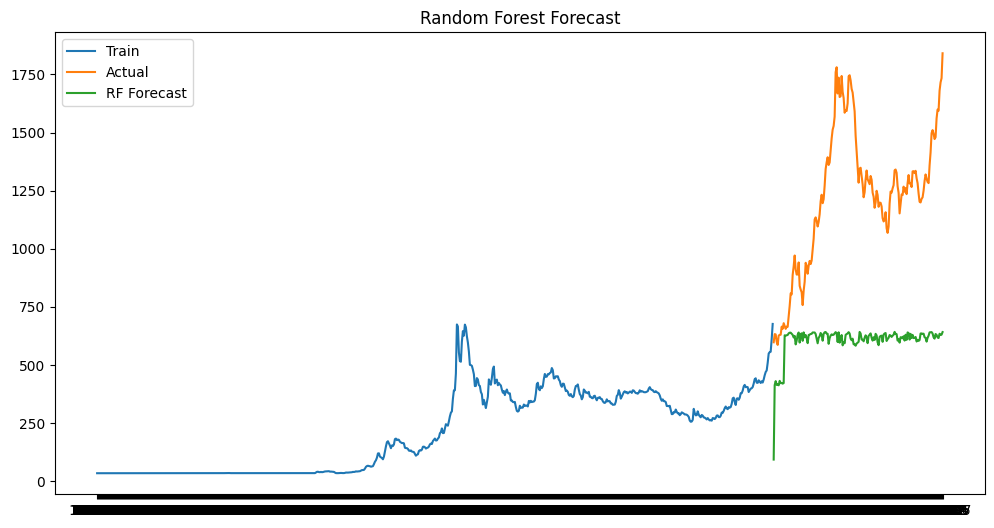

Random Forest RMSE: 677.47
Random Forest MAE: 617.91


In [54]:
## Create time series features
def create_features(df):
    df = df.copy()
    df = df.reset_index()  # Reset index to access 'Date' column
    # Convert 'Date' to datetime if it's not already
    df['Date'] = pd.to_datetime(df['Date'])
    df['month'] = df['Date'].dt.month  # Extract month from 'Date' column
    df['year'] = df['Date'].dt.year   # Extract year from 'Date' column
    df['lag1'] = df['Price'].shift(1)
    df['lag12'] = df['Price'].shift(12)  # yearly seasonality
    df['rolling_mean_12'] = df['Price'].rolling(window=12).mean()

    # Drop the original 'Date' column and 'ARIMA_Forecast', 'RF_Forecast' if present
    # Drop 'Date' column before returning
    # 'errors='ignore'' to avoid error if column doesn't exist
    df = df.drop(['Date', 'ARIMA_Forecast', 'RF_Forecast'], axis=1, errors='ignore')

    return df

# Re-create features after the fix
train_feat = create_features(train)
test_feat = create_features(test)

# Instead of dropping rows with NaN, keep the original index and fill NaN with 0
# This ensures the shapes of test_feat and test are aligned.
train_feat = train_feat.fillna(0)
test_feat = test_feat.fillna(0)

# Separate features and target (again, after the fix)
X_train, y_train = train_feat.drop('Price', axis=1), train_feat['Price']
X_test, y_test = test_feat.drop('Price', axis=1), test_feat['Price']

# Initialize and train Random Forest (same as before)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions and plot (same as before)
# Aligning indices before assignment

# Get predictions first
predictions = rf_model.predict(X_test)
# Aligning indices before assignment to the original test DataFrame
test_feat = test_feat.set_index(test.index)  # Aligning indices if needed
# Now assign to test DataFrame
test['RF_Forecast'] = predictions
# Plot forecasts
plt.figure(figsize=(12, 6))
plt.plot(train['Price'], label='Train')
plt.plot(test['Price'], label='Actual')
plt.plot(test['RF_Forecast'], label='RF Forecast')
plt.title('Random Forest Forecast')
plt.legend()
plt.show()

# Evaluate RMSE for Random Forest Model
rf_rmse = sqrt(mean_squared_error(test['Price'], test['RF_Forecast']))
rf_mae = mean_absolute_error(test['Price'], test['RF_Forecast'])

print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest MAE: {rf_mae:.2f}")

           Model        RMSE         MAE
0          ARIMA  617.902584  547.678893
1  Random Forest  677.467401  617.905540


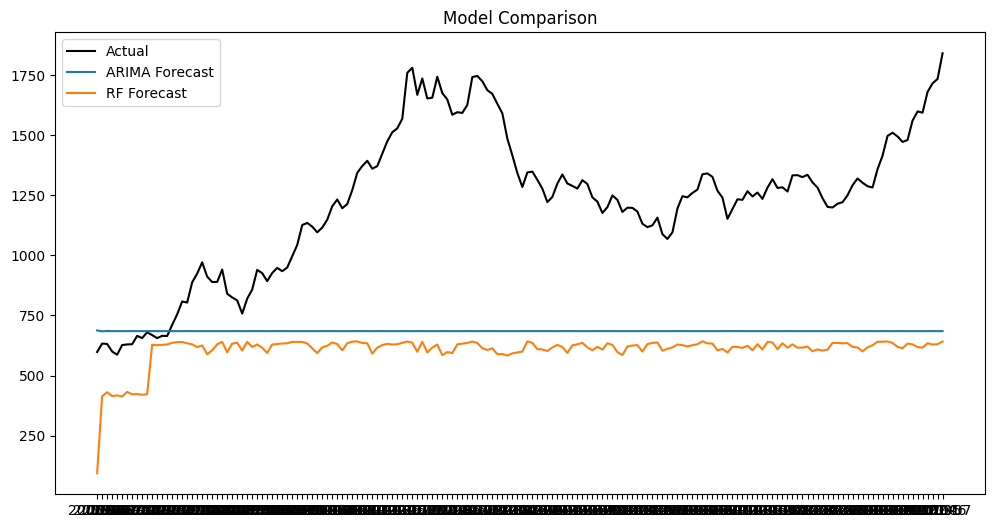

In [55]:
# Compare model performance
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Random Forest'],
    'RMSE': [arima_rmse, rf_rmse],
    'MAE': [arima_mae, rf_mae]
})

print(comparison)

# Plot both forecasts
plt.figure(figsize=(12, 6))
plt.plot(test['Price'], label='Actual', color='black')
plt.plot(test['ARIMA_Forecast'], label='ARIMA Forecast')
plt.plot(test['RF_Forecast'], label='RF Forecast')
plt.title('Model Comparison')
plt.legend()
plt.show()

**SUMMARY**      
ARIMA errors:
**RMSE** = 617.90,
**MAE** = 547.68

Random Forest errors:
**RMSE** = 677.47 ,
**MAE** = 617.91
        
ARIMA's predictions are about $70 closer to the real prices on average